# Notebook 07: Temporal SHAP Analysis
Analyzing how feature importance changes over time (feature drift analysis)

## Cell 1 — Imports

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from src.data.data_loader import (
    load_config,
    load_dataset,
    sample_dataset
)
from src.data.preprocessing import (
    basic_preprocessing_pipeline
)
from src.features.feature_engineering import (
    feature_engineering_pipeline
)
from src.features.encoder import (
    encode_categorical_columns
)
from src.models.train_test_split import (
    temporal_train_test_split,
    split_features_target
)
from src.models.smote_pipeline import (
    apply_smote
)
from src.models.boosting_models import (
    train_xgboost
)
from src.visualization.temporal_shap import (
    compute_yearly_shap_importance,
    plot_temporal_feature_drift,
    get_top_features_by_year
)
from src.evaluation.drift_analysis import (
    compute_feature_drift
)

## Cell 2 — Load + Prepare Dataset

In [2]:
config = load_config()
df = load_dataset(config)
df = sample_dataset(df, config)
df = basic_preprocessing_pipeline(df)
df = feature_engineering_pipeline(df)
train_df, test_df = temporal_train_test_split(df)
X_train, X_test, y_train, y_test = split_features_target(
    train_df,
    test_df
)
X_train, X_test, encoders = encode_categorical_columns(
    X_train,
    X_test
)
X_train_smote, y_train_smote = apply_smote(
    X_train,
    y_train
)

print(f"✓ Data prepared successfully!")
print(f"  Training set (SMOTE): {X_train_smote.shape}")
print(f"  Test set: {X_test.shape}")


Loading dataset from:
/Users/nurnafisfuad/Desktop/AccidentXAI/data/raw/US_Accidents_March23.csv


Dataset loaded successfully.


Sampling 100000 rows...


Starting preprocessing pipeline...

Converting Start_Time to datetime format...
Removed 85 duplicate rows.

Selected relevant columns.

Dropping high-missing columns:

[]

Missing values handled successfully.

Preprocessing completed successfully.


Starting feature engineering pipeline...

Creating temporal features...

Creating rush-hour feature...

Creating night-driving feature...

Simplifying target variable...


Feature engineering completed.


Performing temporal split...

Train Shape: (71919, 30)
Test Shape: (16318, 30)

Separating features and target...

X_train shape: (71919, 29)
X_test shape: (16318, 29)

Encoding categorical columns...

Encoding completed.


Applying SMOTE...

Before SMOTE:

Counter({0: 54138, 1: 17781})

After SMOTE:

Counter({0: 54138, 1: 54138})
✓ Data prepared successfully!
  Training set (SMOTE): (1

## Cell 3 — Train XGBoost

In [3]:
xgb_model = train_xgboost(
    X_train_smote,
    y_train_smote
)

print("✓ XGBoost model trained successfully")


Training XGBoost...

XGBoost training completed.

✓ XGBoost model trained successfully


## Cell 4 — Feature Columns

In [4]:
feature_columns = X_train.columns.tolist()
feature_columns[:10]

['Temperature(F)',
 'Humidity(%)',
 'Pressure(in)',
 'Visibility(mi)',
 'Wind_Speed(mph)',
 'Weather_Condition',
 'Amenity',
 'Bump',
 'Crossing',
 'Give_Way']

## Cell 5 — Compute Yearly SHAP Importance

In [5]:
yearly_shap_df = compute_yearly_shap_importance(
    model=xgb_model,
    df=df,
    feature_columns=feature_columns,
    encoders=encoders,
    sample_size=300
)

yearly_shap_df.head()


Computing yearly SHAP importance...

Processing Year: 2016.0
Processing Year: 2017.0
Processing Year: 2018.0
Processing Year: 2019.0
Processing Year: 2020.0
Processing Year: 2021.0
Processing Year: 2022.0
Processing Year: 2023.0


,Feature,Importance,Year
0,Temperature(F),0.012638,2016.0
1,Humidity(%),0.014406,2016.0
2,Pressure(in),0.010031,2016.0
3,Visibility(mi),0.007965,2016.0
4,Wind_Speed(mph),0.026013,2016.0


## Cell 6 — IMPORTANT RESEARCH INSIGHT

> **We use smaller yearly SHAP samples because:**
> 
> Temporal SHAP is computationally expensive.
> 
> Research practicality matters.
> 
> *"Better to have approximate answers than exact but late ones."*

## Cell 7 — Plot Temporal Feature Drift

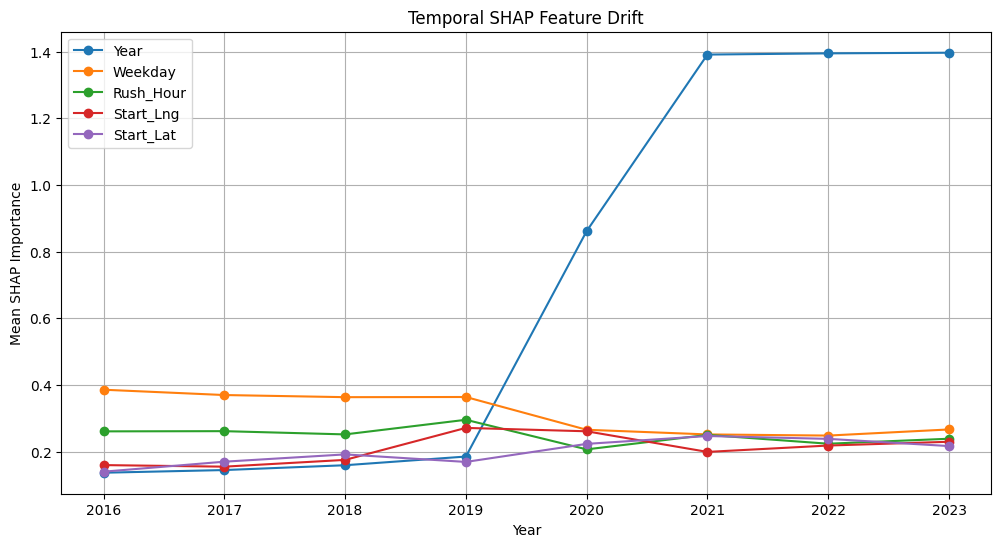

In [6]:
plot_temporal_feature_drift(
    yearly_shap_df,
    top_n=5
)

## Cell 8 — What You Should Observe

**Some features may remain stable.**

**Others may drift significantly.**

| Feature | Behavior |
|---------|----------|
| Night Driving | stable |
| Visibility | increasing |
| Weather | fluctuating |

---

**This becomes publishable insight.**

Understanding *why* features drift can lead to:
- Better model retraining strategies
- Domain-specific insights about changing conditions
- Improved feature engineering

## Cell 9 — Drift Analysis Table

In [7]:
drift_df = compute_feature_drift(
    yearly_shap_df
)
drift_df.head(15)

,Feature,min,max,mean,Drift_Range
28,Year,0.136442,1.396842,0.708680,1.260400
8,Month,0.043579,0.338679,0.145427,0.295100
26,Weekday,0.247911,0.385528,0.314105,0.137617
23,Traffic_Signal,0.097002,0.225073,0.159654,0.128071
16,Start_Lng,0.154633,0.270939,0.208365,0.116306
15,Start_Lat,0.139593,0.246593,0.199184,0.107000
9,Night_Driving,0.042328,0.135222,0.065054,0.092894
14,Rush_Hour,0.206506,0.295297,0.248352,0.088791
20,Sunrise_Sunset,0.031172,0.088728,0.056543,0.057556
5,Hour,0.164978,0.206340,0.182850,0.041362


## Cell 10 — Top Features By Year

In [8]:
top_features = get_top_features_by_year(
    yearly_shap_df,
    top_n=5
)
top_features

{np.float64(2016.0):            Feature  Importance    Year
 26         Weekday    0.385528  2016.0
 27       Rush_Hour    0.260572  2016.0
 17  Traffic_Signal    0.219150  2016.0
 25            Hour    0.189752  2016.0
 21       Start_Lng    0.159340  2016.0,
 np.float64(2017.0):            Feature  Importance    Year
 55         Weekday    0.369573  2017.0
 56       Rush_Hour    0.261168  2017.0
 46  Traffic_Signal    0.203830  2017.0
 54            Hour    0.180001  2017.0
 49       Start_Lat    0.169530  2017.0,
 np.float64(2018.0):            Feature  Importance    Year
 84         Weekday    0.363168  2018.0
 85       Rush_Hour    0.251442  2018.0
 75  Traffic_Signal    0.225073  2018.0
 78       Start_Lat    0.191437  2018.0
 83            Hour    0.177665  2018.0,
 np.float64(2019.0):             Feature  Importance    Year
 113         Weekday    0.363681  2019.0
 114       Rush_Hour    0.295297  2019.0
 108       Start_Lng    0.270939  2019.0
 104  Traffic_Signal    0.197961 

## Optional Cell 11 — Drift Visualization Heatmap

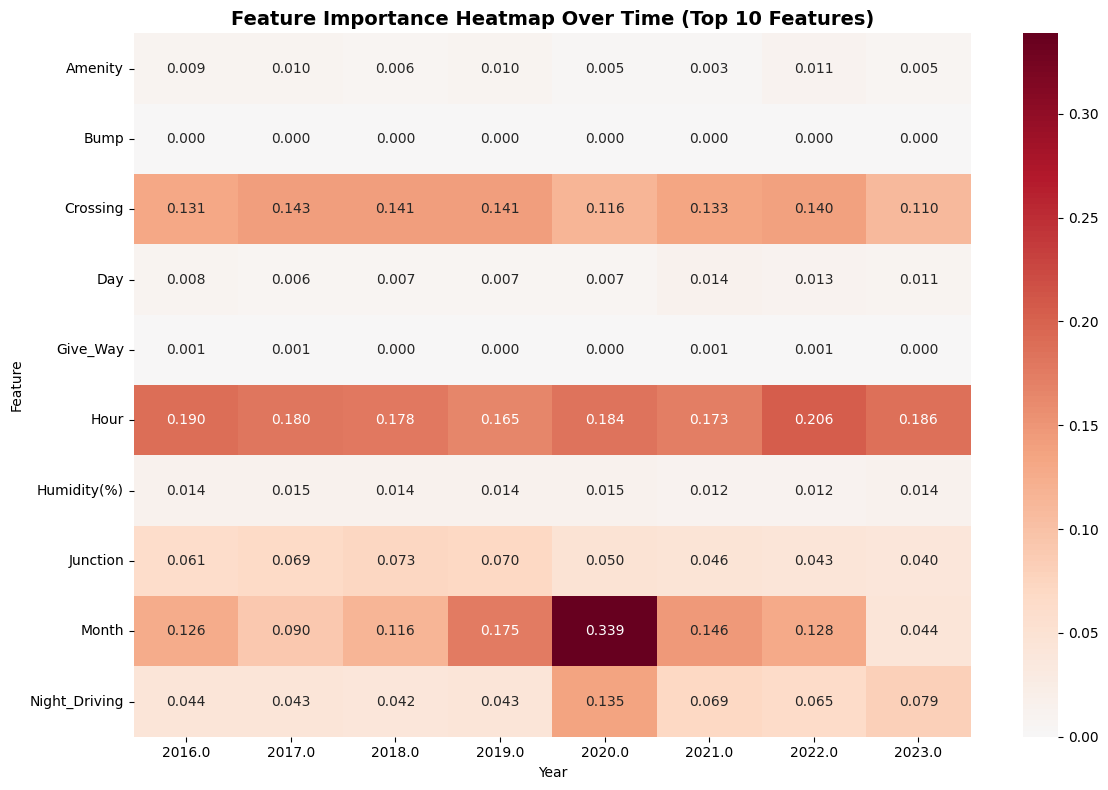

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot table for heatmap
pivot_df = yearly_shap_df.pivot(
    index='Feature',
    columns='Year',
    values='Importance'
)

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    pivot_df.head(10),
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0
)

plt.title(
    'Feature Importance Heatmap Over Time (Top 10 Features)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Year')

plt.ylabel('Feature')

plt.tight_layout()

plt.show()

## Optional Cell 12 — Stability Score Analysis

In [15]:
# Calculate stability score
# (inverse coefficient of variation)

stability_df = yearly_shap_df.groupby(
    'Feature'
)['Importance'].agg(
    ['mean', 'std']
)

# Coefficient of variation
stability_df['cv'] = (
    stability_df['std'] /
    stability_df['mean']
)

# Stability score
stability_df['stability_score'] = (
    1 / stability_df['cv']
)

# Sort by stability
stability_df = stability_df.sort_values(
    'stability_score',
    ascending=False
)

print(
    "Feature Stability Scores "
    "(higher = more stable):"
)

print(
    stability_df[
        ['mean', 'std', 'stability_score']
    ].head(10)
)

print("\n\nMost Unstable Features (potential drift):")

print(
    stability_df[
        ['mean', 'std', 'stability_score']
    ].tail(10)
)

Feature Stability Scores (higher = more stable):
                       mean       std  stability_score
Feature                                               
Hour               0.182850  0.012276        14.894846
State              0.145640  0.011295        12.893998
Humidity(%)        0.013866  0.001103        12.571990
Temperature(F)     0.011614  0.001021        11.377591
Crossing           0.131720  0.012551        10.495200
Stop               0.036948  0.003926         9.410428
Rush_Hour          0.248352  0.026718         9.295134
Weather_Condition  0.024170  0.002848         8.486669
Wind_Speed(mph)    0.031421  0.005792         5.424675
Start_Lat          0.199184  0.037857         5.261434


Most Unstable Features (potential drift):
                    mean       std  stability_score
Feature                                            
Amenity         0.007364  0.002730         2.697977
Sunrise_Sunset  0.056543  0.023842         2.371565
Pressure(in)    0.016372  0.006955     